In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls /content/drive/MyDrive

'Colab Notebooks'   SonarDetectObject.v1-sonar_plane_ship.yolov8


In [4]:
!ls /content/drive/MyDrive/SonarDetectObject.v1-sonar_plane_ship.yolov8/

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [5]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.7 MB/s eta 0:00:00


In [6]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [9]:
model = YOLO("yolov8n.pt")

In [7]:
!nvidia-smi

Sun Sep  6 15:55:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
yaml_path = "/content/drive/MyDrive/sonardetect/data.yaml"

print(yaml_path)

/content/drive/MyDrive/sonardetect/data.yaml


In [10]:
from PIL import Image
import os

image_dir = "/content/drive/MyDrive/SonarDetectObject.v1-sonar_plane_ship.yolov8/train/images"

images = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Number of images:", len(images))

if images:
    img = Image.open(os.path.join(image_dir, images[0]))
    print("First image shape:", img.size)
    print("Image mode:", img.mode)

Number of images: 675
First image shape: (416, 416)
Image mode: RGB


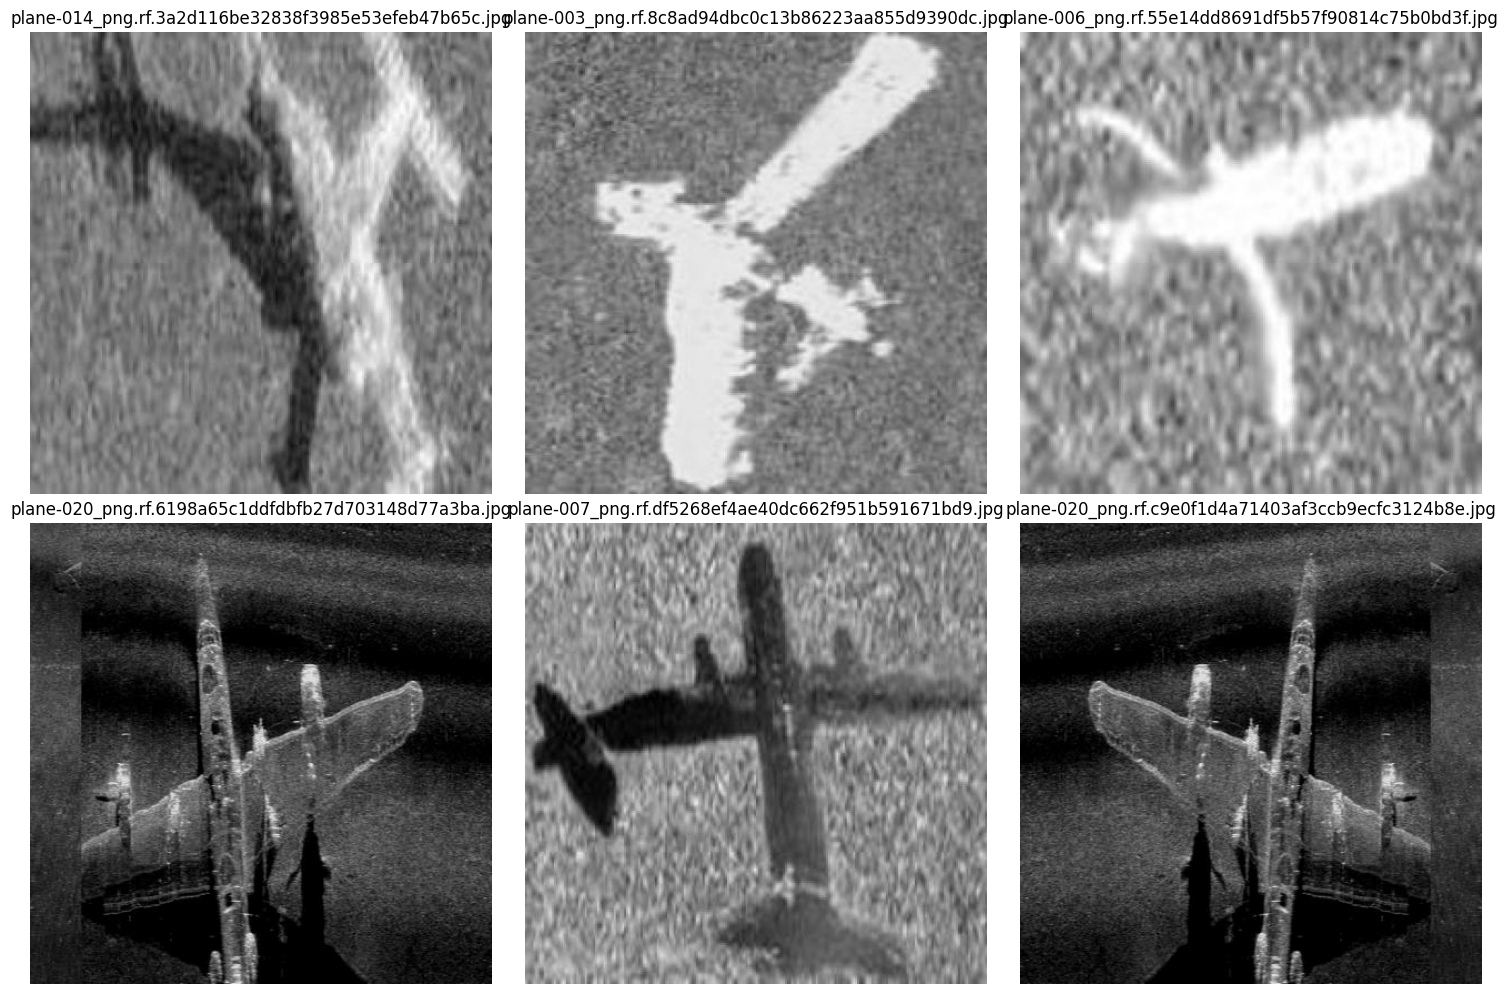

In [11]:
import os
import matplotlib.pyplot as plt
from PIL import Image

image_dir = "/content/drive/MyDrive/SonarDetectObject.v1-sonar_plane_ship.yolov8/train/images"

# Get image files
images = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Select first 6 images
sample_images = images[:6]

# Display images
plt.figure(figsize=(15, 10))

for i, image_name in enumerate(sample_images):
    image_path = os.path.join(image_dir, image_name)
    img = Image.open(image_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(image_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

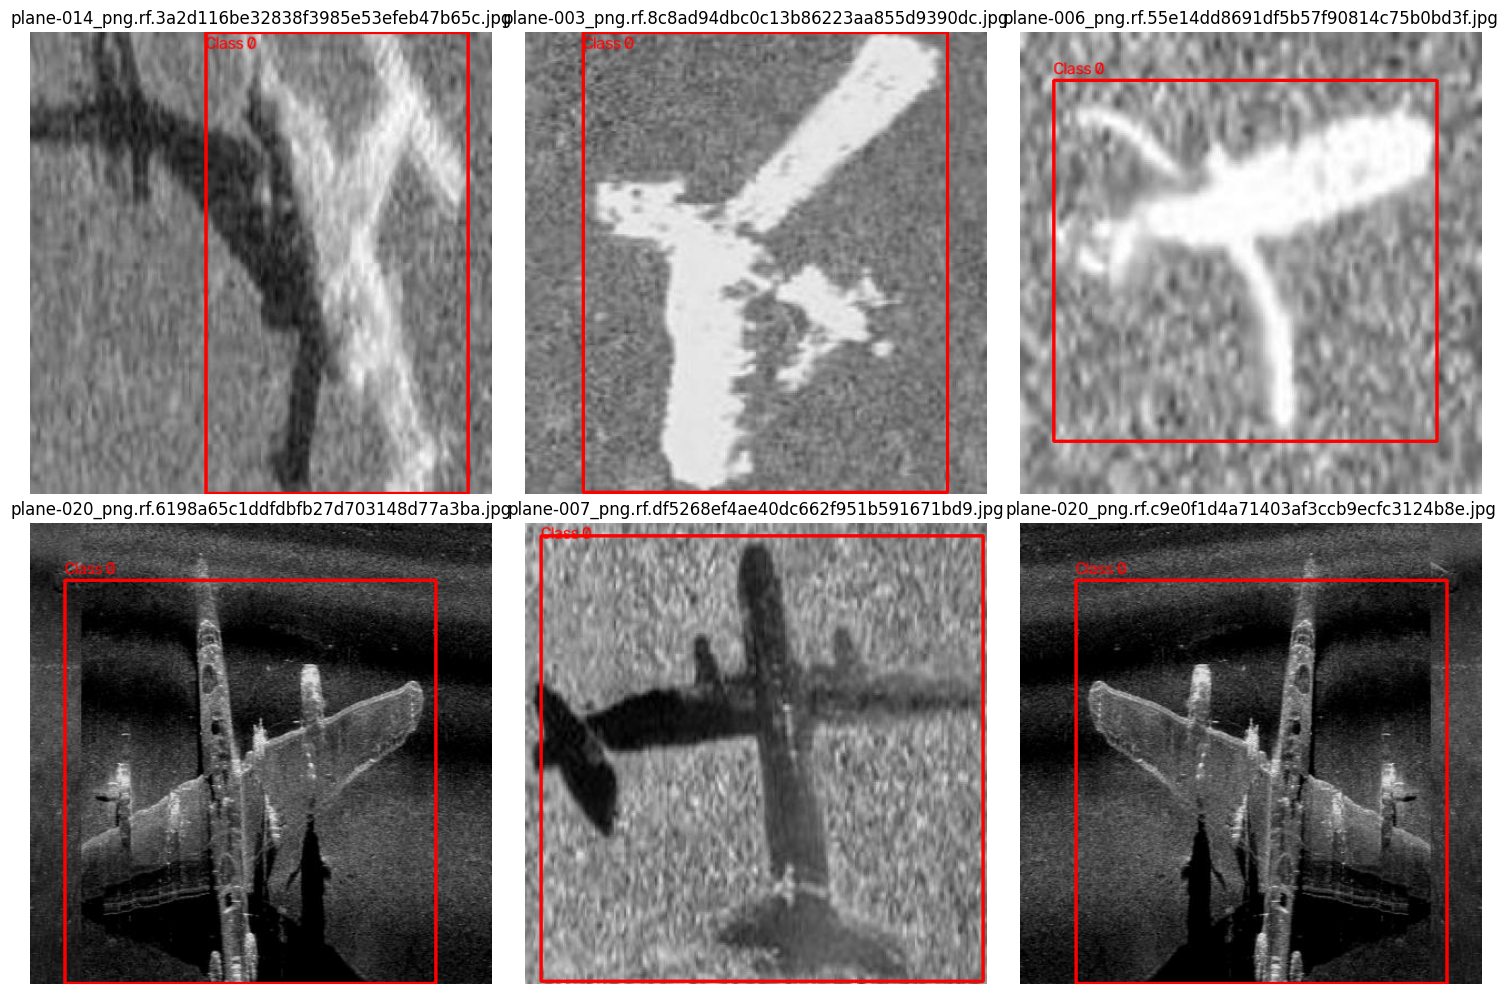

In [12]:
import os
import cv2
import matplotlib.pyplot as plt

image_dir = "/content/drive/MyDrive/SonarDetectObject.v1-sonar_plane_ship.yolov8/train/images"
label_dir = "/content/drive/MyDrive/SonarDetectObject.v1-sonar_plane_ship.yolov8/train/labels"

images = [
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

sample_images = images[:6]

plt.figure(figsize=(15, 10))

for i, image_name in enumerate(sample_images):

    image_path = os.path.join(image_dir, image_name)
    label_path = os.path.join(
        label_dir,
        os.path.splitext(image_name)[0] + ".txt"
    )

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    # Draw YOLO bounding boxes
    if os.path.exists(label_path):

        with open(label_path, "r") as f:
            for line in f:
                values = line.strip().split()

                if len(values) != 5:
                    continue

                class_id, xc, yc, bw, bh = map(float, values)

                # Convert YOLO coordinates to pixel coordinates
                x1 = int((xc - bw / 2) * w)
                y1 = int((yc - bh / 2) * h)
                x2 = int((xc + bw / 2) * w)
                y2 = int((yc + bh / 2) * h)

                cv2.rectangle(
                    img,
                    (x1, y1),
                    (x2, y2),
                    (255, 0, 0),
                    2
                )

                cv2.putText(
                    img,
                    f"Class {int(class_id)}",
                    (x1, max(y1 - 5, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (255, 0, 0),
                    1
                )

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(image_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
results = model.train(
    data="/content/drive/MyDrive/SonarDetectObject.v1-sonar_plane_ship.yolov8/data.yaml",
    epochs=50,
    imgsz=416,
    batch=16,
    device=0,
    project="/content/drive/MyDrive/sonar_yolo",
    name="sonar_detection"
)

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/SonarDetectObject.v1-sonar_plane_ship.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, nam